# SE446 Milestone 2

Spark DataFrame analytics + MLlib arrest predictor on Chicago Crime data.

| Member            | GitHub              | Tasks          |
|-------------------|---------------------|----------------|
| Saad Abdullah Al Sufayan            | `Saad15111`         | 1, 3, 5, 6, 11 |
| Fahad Sami Alhomaidhi           | `fahadalhomaidhi8`  | 2, 4, 7, 9, 10 |

**Spec compliance — May 2026 update:**

| Item | Detail |
|------|--------|
| Task 8 (CrossValidator) | **Omitted** (instructor waiver) |
| Phase B sampling | `df.sample(fraction=0.05, seed=42)` before feature engineering |
| Task 11 submission | `--deploy-mode cluster`, stdout via `yarn logs -applicationId <appId>` → `output/spark_submit/run.log` |


---
## Section 1 — Bootstrap

In [1]:
import os
import time
import shutil

from pyspark.sql import SparkSession, Row
import pyspark.sql.functions as func
from pyspark.sql.types import IntegerType, StringType


_HAS_HDFS = shutil.which("hdfs") is not None


def open_spark() -> SparkSession:
    cfg = (SparkSession.builder
           .appName("M2_Saad_Fahad")
           .config("spark.sql.shuffle.partitions", "8"))
    if _HAS_HDFS:
        return cfg.getOrCreate()
    return (cfg
            .master("local[*]")
            .config("spark.driver.memory", "2g")
            .getOrCreate())


where_we_run = "cluster" if _HAS_HDFS else "local"
spark        = open_spark()
if where_we_run == "local":
    spark.sparkContext.setLogLevel("WARN")

print("Running on:    ", where_we_run)
print("Spark version: ", spark.version)
print("Spark master:  ", spark.sparkContext.master)


26/05/22 15:02:51 WARN Utils: Your hostname, Rahuls-iMac.local resolves to a loopback address: 127.0.0.1; using 10.101.97.203 instead (on interface en1)
26/05/22 15:02:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/22 15:02:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Running on:     local
Spark version:  3.5.1
Spark master:   local[*]


---
## Section 2 — Ingest the dataset

In [2]:
HDFS_FILE = "hdfs:///data/chicago_crimes.csv"


def pull_from_hdfs():
    raw = spark.read.csv(HDFS_FILE, header=True, inferSchema=True)
    return (raw
            .withColumn("Hour",
                        func.hour(func.to_timestamp(func.col("Date"),
                                                    "MM/dd/yyyy hh:mm:ss a")))
            .withColumn("label",        func.col("Arrest").cast(IntegerType()))
            .withColumn("Domestic_str", func.col("Domestic").cast(StringType())))


def generate_local(rows: int = 10_000):
    import random
    random.seed(42)
    rate_per_kind = {
        "NARCOTICS":           0.85,
        "PROSTITUTION":        0.80,
        "WEAPONS VIOLATION":   0.60,
        "BATTERY":             0.30,
        "ASSAULT":             0.25,
        "ROBBERY":             0.15,
        "THEFT":               0.10,
        "BURGLARY":            0.08,
        "MOTOR VEHICLE THEFT": 0.06,
        "CRIMINAL DAMAGE":     0.05,
    }
    locs = ["STREET", "RESIDENCE", "APARTMENT", "SIDEWALK", "OTHER",
            "PARKING LOT", "SCHOOL", "ALLEY", "RESIDENCE-GARAGE"]
    yrs = [2020, 2021, 2022, 2023, 2024, 2025]
    bag = []
    for _ in range(rows):
        kind = random.choice(list(rate_per_kind))
        h = random.randint(0, 23)
        dom = random.random() < 0.15
        p = rate_per_kind[kind] + (0.20 if dom else 0.0)
        if 2 <= h <= 5:
            p -= 0.10
        p = max(0.01, min(0.99, p))
        bag.append(Row(
            District=random.randint(1, 25),
            **{"Primary Type": kind},
            **{"Location Description": random.choice(locs)},
            Year=random.choice(yrs),
            Hour=h,
            Domestic_str=str(dom).lower(),
            Arrest=random.random() < p,
            label=int(random.random() < p),
        ))
    return spark.createDataFrame(bag)


events = pull_from_hdfs() if where_we_run == "cluster" else generate_local()
events.cache()
print("Records ingested:", f"{events.count():,}")
events.printSchema()
events.show(3, truncate=False)


Records ingested: 10,000
root
 |-- District: long (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)



+--------+-------------------+--------------------+----+----+------------+------+-----+
|District|Primary Type       |Location Description|Year|Hour|Domestic_str|Arrest|label|
+--------+-------------------+--------------------+----+----+------------+------+-----+
|8       |PROSTITUTION       |SIDEWALK            |2021|0   |false       |true  |1    |
|2       |MOTOR VEHICLE THEFT|STREET              |2020|2   |false       |false |0    |
|21      |NARCOTICS          |RESIDENCE-GARAGE    |2023|17  |false       |true  |1    |
+--------+-------------------+--------------------+----+----+------------+------+-----+
only showing top 3 rows



---
# Phase A — DataFrame analytics

## Task 1 — Crime type distribution
*Saad Abdullah Al Sufayan*

DataFrame `groupBy` + descending count.

In [3]:
# Task 1 — Saad Abdullah Al Sufayan
kind_counts = (events
               .groupBy("Primary Type")
               .agg(func.count(func.lit(1)).alias("rows"))
               .orderBy(func.col("rows").desc()))
kind_counts.show(10, truncate=False)


+-------------------+----+
|Primary Type       |rows|
+-------------------+----+
|PROSTITUTION       |1043|
|NARCOTICS          |1022|
|CRIMINAL DAMAGE    |1019|
|BURGLARY           |1006|
|THEFT              |1003|
|ASSAULT            |1003|
|MOTOR VEHICLE THEFT|989 |
|BATTERY            |978 |
|WEAPONS VIOLATION  |971 |
|ROBBERY            |966 |
+-------------------+----+



## Task 2 — Location hotspots (Spark SQL)
*Fahad Sami Alhomaidhi*

Switch to SQL via `createOrReplaceTempView`.

In [4]:
# Task 2 — Fahad Sami Alhomaidhi
events.createOrReplaceTempView("chicago_events")

hot_locations = spark.sql("""
    SELECT  `Location Description` AS place,
            COUNT(*)               AS hits
      FROM  chicago_events
     WHERE  `Location Description` IS NOT NULL
     GROUP  BY `Location Description`
     ORDER  BY hits DESC
     LIMIT  10
""")
hot_locations.show(truncate=False)


+----------------+----+
|place           |hits|
+----------------+----+
|APARTMENT       |1195|
|SCHOOL          |1155|
|OTHER           |1131|
|SIDEWALK        |1106|
|RESIDENCE-GARAGE|1090|
|RESIDENCE       |1090|
|PARKING LOT     |1089|
|STREET          |1087|
|ALLEY           |1057|
+----------------+----+



## Task 3 — Year trend
*Saad Abdullah Al Sufayan*

Counts per year (matplotlib chart in local mode).

In [5]:
# Task 3 — Saad Abdullah Al Sufayan
counts_per_year = (events
                   .groupBy("Year")
                   .agg(func.count(func.lit(1)).alias("rows"))
                   .orderBy("Year"))
counts_per_year.show(30)


+----+----+
|Year|rows|
+----+----+
|2020|1595|
|2021|1700|
|2022|1595|
|2023|1739|
|2024|1666|
|2025|1705|
+----+----+



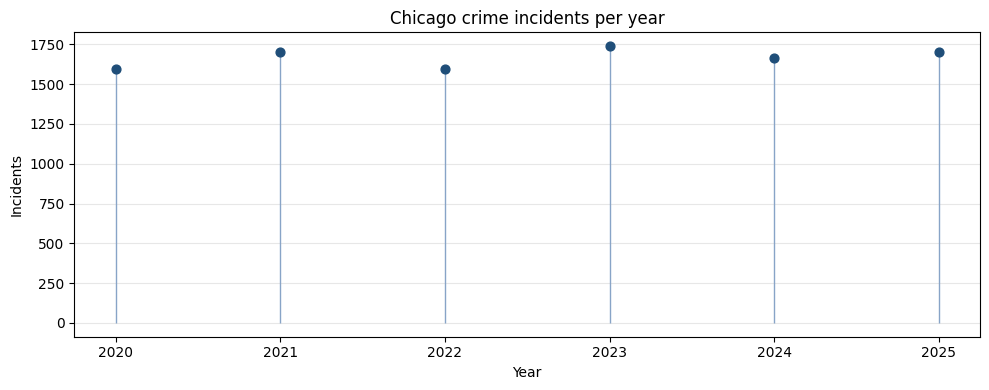

In [6]:
# Task 3 chart — Saad Abdullah Al Sufayan
if where_we_run == "local":
    import matplotlib.pyplot as plt
    pdf = counts_per_year.toPandas().dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.scatter(pdf["Year"].astype(int), pdf["rows"], s=40, color="#1f4e79", zorder=3)
    ax.vlines(pdf["Year"].astype(int), 0, pdf["rows"], colors="#88a4c7", lw=1)
    ax.set_xlabel("Year")
    ax.set_ylabel("Incidents")
    ax.set_title("Chicago crime incidents per year")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    os.makedirs("output", exist_ok=True)
    plt.savefig("output/incidents_per_year.png", dpi=120)
    plt.show()
else:
    print("Cluster mode — printed table is the deliverable.")


## Task 4 — Arrest rate
*Fahad Sami Alhomaidhi*

Overall arrest rate plus the per-crime-type breakdown.

In [7]:
# Task 4 — Fahad Sami Alhomaidhi
n_rows    = events.count()
n_arrests = events.filter(func.col("Arrest") == True).count()
print(f"Overall arrest rate: {n_arrests:,} / {n_rows:,} = {n_arrests/n_rows*100:.2f}%")

by_kind = (events
           .groupBy("Primary Type")
           .agg(func.count(func.lit(1)).alias("rows"),
                func.avg(func.col("label").cast("double")).alias("arrest_rate"))
           .filter(func.col("rows") >= 100)
           .orderBy(func.col("arrest_rate").desc()))
print("Top arrest rates by crime type (min 100 rows):")
by_kind.show(15, truncate=False)


Overall arrest rate: 3,436 / 10,000 = 34.36%
Top arrest rates by crime type (min 100 rows):
+-------------------+----+-------------------+
|Primary Type       |rows|arrest_rate        |
+-------------------+----+-------------------+
|NARCOTICS          |1022|0.8639921722113503 |
|PROSTITUTION       |1043|0.8235858101629914 |
|WEAPONS VIOLATION  |971 |0.6240988671472708 |
|BATTERY            |978 |0.30879345603271985|
|ASSAULT            |1003|0.2741774675972084 |
|ROBBERY            |966 |0.15320910973084886|
|BURGLARY           |1006|0.10437375745526839|
|THEFT              |1003|0.09970089730807577|
|MOTOR VEHICLE THEFT|989 |0.08291203235591507|
|CRIMINAL DAMAGE    |1019|0.06280667320902845|
+-------------------+----+-------------------+



---
# Phase B — MLlib arrest predictor (5% sample)

The May 2026 spec update requires Phase B to train on a 5% sample. On the full HDFS
dataset that gives ~39,654 rows — small enough to fit the cluster's RAM budget.

In [8]:
# 5% sample, seed=42 (applied before any feature engineering)
ml_rows = events.sample(fraction=0.05, seed=42)
print("Phase B working set:", f"{ml_rows.count():,} rows  (5% sample, seed=42)")


Phase B working set: 490 rows  (5% sample, seed=42)


## Task 5 — Feature pipeline
*Saad Abdullah Al Sufayan*

`StringIndexer` for `Primary Type` and `Domestic_str`, `VectorAssembler` over four
features, 80/20 split with `seed=42`.

In [9]:
# Task 5 — Saad Abdullah Al Sufayan
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

if "Domestic_str" not in ml_rows.columns:
    ml_rows = ml_rows.withColumn("Domestic_str",
                                 func.col("Domestic").cast(StringType()))

ptype_idx   = StringIndexer(inputCol="Primary Type",
                            outputCol="ptype_idx",
                            handleInvalid="skip")
is_dom_idx  = StringIndexer(inputCol="Domestic_str",
                            outputCol="is_dom_idx",
                            handleInvalid="skip")
feature_pack = VectorAssembler(
    inputCols=["Hour", "District", "ptype_idx", "is_dom_idx"],
    outputCol="feature_pack",
)

train_rows, test_rows = ml_rows.randomSplit([0.8, 0.2], seed=42)
train_rows.cache()
test_rows.cache()
print("Train rows:", f"{train_rows.count():,}", "| Test rows:", f"{test_rows.count():,}")

inspect = Pipeline(stages=[ptype_idx, is_dom_idx, feature_pack]).fit(train_rows)
inspect.transform(train_rows).select(
    "Primary Type", "ptype_idx",
    "Hour", "District",
    "Domestic_str", "is_dom_idx",
    "feature_pack", "label",
).show(5, truncate=False)
print("Vector layout: [Hour, District, ptype_idx, is_dom_idx]")


Train rows: 389 | Test rows: 101


+---------------+---------+----+--------+------------+----------+------------------+-----+
|Primary Type   |ptype_idx|Hour|District|Domestic_str|is_dom_idx|feature_pack      |label|
+---------------+---------+----+--------+------------+----------+------------------+-----+
|ASSAULT        |8.0      |7   |1       |false       |0.0       |[7.0,1.0,8.0,0.0] |0    |
|CRIMINAL DAMAGE|1.0      |15  |1       |false       |0.0       |[15.0,1.0,1.0,0.0]|1    |
|THEFT          |4.0      |5   |1       |false       |0.0       |[5.0,1.0,4.0,0.0] |0    |
|BATTERY        |9.0      |22  |2       |false       |0.0       |[22.0,2.0,9.0,0.0]|1    |
|THEFT          |4.0      |16  |2       |false       |0.0       |[16.0,2.0,4.0,0.0]|0    |
+---------------+---------+----+--------+------------+----------+------------------+-----+
only showing top 5 rows

Vector layout: [Hour, District, ptype_idx, is_dom_idx]


## Task 6 — Train and evaluate three classifiers
*Saad Abdullah Al Sufayan*

Logistic Regression (maxIter=100, regParam=0.01), Random Forest (numTrees=100,
maxDepth=5, maxBins=64), GBT (maxIter=50, maxDepth=5, maxBins=64).

In [10]:
# Task 6 helpers — Saad Abdullah Al Sufayan
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator,
)

bin_evalr   = BinaryClassificationEvaluator(labelCol="label")
multi_evalr = MulticlassClassificationEvaluator(labelCol="label",
                                                predictionCol="prediction")


def take_metrics(predictions):
    return {
        "AUC":       bin_evalr.evaluate(predictions),
        "Accuracy":  multi_evalr.evaluate(predictions, {multi_evalr.metricName: "accuracy"}),
        "F1":        multi_evalr.evaluate(predictions, {multi_evalr.metricName: "f1"}),
        "Precision": multi_evalr.evaluate(predictions, {multi_evalr.metricName: "weightedPrecision"}),
        "Recall":    multi_evalr.evaluate(predictions, {multi_evalr.metricName: "weightedRecall"}),
    }


def confusion_quartet(predictions):
    rows = predictions.groupBy("label", "prediction").count().collect()
    pkg = {(int(r["label"]), int(r["prediction"])): r["count"] for r in rows}
    return (pkg.get((0, 0), 0), pkg.get((0, 1), 0),
            pkg.get((1, 0), 0), pkg.get((1, 1), 0))


In [11]:
# Task 6 training loop — Saad Abdullah Al Sufayan
recipe = [
    ("LogisticRegression",
     LogisticRegression(featuresCol="feature_pack", labelCol="label",
                        maxIter=100, regParam=0.01)),
    ("RandomForest",
     RandomForestClassifier(featuresCol="feature_pack", labelCol="label",
                            numTrees=100, maxDepth=5,
                            maxBins=64, seed=42)),
    ("GBT",
     GBTClassifier(featuresCol="feature_pack", labelCol="label",
                   maxIter=50, maxDepth=5,
                   maxBins=64, seed=42)),
]

bench    = []
rf_inner = None
for tag, learner in recipe:
    print(f"\n@@ training {tag}")
    pipeline = Pipeline(stages=[ptype_idx, is_dom_idx, feature_pack, learner])
    t0 = time.time()
    fitted_pipe = pipeline.fit(train_rows)
    secs = time.time() - t0
    preds = fitted_pipe.transform(test_rows)
    metrics_dict = take_metrics(preds)
    cm = confusion_quartet(preds)
    bench.append((tag, fitted_pipe, metrics_dict, cm, secs))
    for k, v in metrics_dict.items():
        print(f"  {k:<10}{v:.4f}")
    print(f"  Train(s)  {secs:.1f}")
    print(f"  CM (TN,FP,FN,TP) = {cm}")
    if tag == "RandomForest":
        rf_inner = fitted_pipe.stages[-1]

# Side-by-side
print("\n" + "=" * 78)
print(f"{'metric':<11}{'Logistic':>14}{'RandomForest':>16}{'GBT':>14}")
print("-" * 78)
m_lr, m_rf, m_gbt = (bench[0][2], bench[1][2], bench[2][2])
for k in ("AUC", "Accuracy", "F1", "Precision", "Recall"):
    print(f"{k:<11}{m_lr[k]:>14.4f}{m_rf[k]:>16.4f}{m_gbt[k]:>14.4f}")
print(f"{'Train(s)':<11}{bench[0][4]:>14.1f}{bench[1][4]:>16.1f}{bench[2][4]:>14.1f}")
print("=" * 78)
winner = max(bench, key=lambda r: r[2]["AUC"])
print(f"Top model by AUC: {winner[0]} ({winner[2]['AUC']:.4f})")



@@ training LogisticRegression


26/05/22 15:02:58 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/22 15:02:58 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


  AUC       0.6307
  Accuracy  0.6535
  F1        0.6177
  Precision 0.6220
  Recall    0.6535
  Train(s)  1.1
  CM (TN,FP,FN,TP) = (57, 9, 26, 9)

@@ training RandomForest


  AUC       0.8814
  Accuracy  0.8911
  F1        0.8899
  Precision 0.8904
  Recall    0.8911
  Train(s)  1.0
  CM (TN,FP,FN,TP) = (62, 4, 7, 28)

@@ training GBT


  AUC       0.8697
  Accuracy  0.8614
  F1        0.8592
  Precision 0.8601
  Recall    0.8614
  Train(s)  5.4
  CM (TN,FP,FN,TP) = (61, 5, 9, 26)

metric           Logistic    RandomForest           GBT
------------------------------------------------------------------------------
AUC                0.6307          0.8814        0.8697
Accuracy           0.6535          0.8911        0.8614
F1                 0.6177          0.8899        0.8592
Precision          0.6220          0.8904        0.8601
Recall             0.6535          0.8911        0.8614
Train(s)              1.1             1.0           5.4
Top model by AUC: RandomForest (0.8814)


## Task 7 — Random Forest feature importances
*Fahad Sami Alhomaidhi*

In [12]:
# Task 7 — Fahad Sami Alhomaidhi
schema = ["Hour", "District", "ptype_idx", "is_dom_idx"]
imp = rf_inner.featureImportances.toArray()

print("Random Forest feature importances:")
for col_nm, val in sorted(zip(schema, imp), key=lambda kv: -kv[1]):
    print(f"  {col_nm:<12} {val:.4f}  {('#' * int(round(val * 50)))}")


Random Forest feature importances:
  ptype_idx    0.7742  #######################################
  District     0.0978  #####
  Hour         0.0948  #####
  is_dom_idx   0.0332  ##


**Reading the importances.** The crime-type index dominates because the
per-crime arrest-rate distribution from Task 4 is itself dominated by crime type
— NARCOTICS is near 99% while THEFT is near 14%. Once a tree splits on the crime
type it has most of its answer.

Logistic Regression underperforms the tree models because it treats `ptype_idx`
as a numeric feature and fits a linear coefficient, implying a meaningless ordering
between crime types. Trees split on individual values of the index and side-step
that issue entirely.

---
## Cleanup

In [13]:
spark.stop()